# scikit-learn Dataset Transformations — Practical Guide

Every transformer in sklearn follows the same shape: `.fit()` learns something from your training data (like "the mean of this column is 4.2"), `.transform()` applies that learned rule to any data (train or test). `.fit_transform()` just does both at once on training data. That's the whole mental model — keep it in your head as you read everything below.

**Golden rule for tomorrow:** always `fit` on training data only, then `transform` both train and test (or better, wrap everything in a `Pipeline` so you can't mess this up). Fitting on test data too = data leakage = your local score lies to you.

---

## 8.1 Pipelines and composite estimators — *the glue, not optional*

**What it is:** A `Pipeline` chains transformers + a final model into one object, so `pipeline.fit(X_train, y_train)` does all your preprocessing AND trains the model in one call. `ColumnTransformer` lets you apply *different* preprocessing to different columns (e.g., scale numeric columns, one-hot encode categorical ones) in one step.

**Why you care:** Without this, it's easy to accidentally fit your scaler on the full dataset (leakage) or forget to apply the same transformation to test data. With a Pipeline, cross-validation and `GridSearchCV` handle the fit/transform split correctly for you automatically.

**When to use:** Basically always, for a competition. Use `ColumnTransformer` the moment you have both numeric and categorical columns (which is almost every Kaggle tabular dataset).

```python
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

num_cols = ['age', 'income']
cat_cols = ['city', 'gender']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('impute', SimpleImputer(strategy='median')),
                       ('scale', StandardScaler())]), num_cols),
    ('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                       ('encode', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

full_pipeline = Pipeline([('prep', preprocessor), ('model', your_model)])
full_pipeline.fit(X_train, y_train)
```

- **FeatureUnion**: combines outputs of *parallel* transformers into one feature set (mostly superseded by ColumnTransformer for tabular data — you won't need it much).
- **Transforming target in regression** (`TransformedTargetRegressor`): if your target `y` is skewed (e.g. house prices), you can log-transform `y` before fitting and auto-un-transform predictions. Handy if your metric is RMSE on a skewed target.

---

## 8.3 Preprocessing data — *this is where you'll spend most of your time*

### Standardization / Scaling
**Intuition:** Puts all numeric features on the same scale so no single feature dominates just because its numbers are bigger (e.g., "income in rupees" vs "age in years").
- `StandardScaler`: mean=0, std=1. Default choice, works well for most models.
- `MinMaxScaler`: squashes to [0,1]. Use if you need bounded values (e.g., neural nets, or a feature that's already bounded).
- `RobustScaler`: uses median/IQR instead of mean/std — use when you have outliers you don't want to remove but don't want dominating the scaling.

**When you actually need it:** Linear models, SVM, KNN, neural nets, PCA — all care about scale. **Tree-based models (Random Forest, XGBoost, LightGBM, CatBoost) don't need scaling at all** — trees split on thresholds, not distances. If your competition says "which model to train" is already given and it's a tree ensemble, you can often skip scaling entirely and save time.

### Non-linear transformation
**Intuition:** Sometimes a feature's *relationship* to the target isn't linear — e.g., income has huge outliers and a long right tail. `PowerTransformer` (Box-Cox/Yeo-Johnson) or `QuantileTransformer` reshape the distribution to be more Gaussian/uniform, which helps linear models especially.
**When:** Skewed numeric features, especially for linear/distance-based models. Skip for tree models — they don't care about distribution shape, only ordering (monotonic transforms don't change split points).

### Normalization (`Normalizer`)
**Intuition:** This one's often confused with scaling but is different — it scales each *row* (sample) to unit norm, not each column. Used when the direction of the feature vector matters more than magnitude (common in text/TF-IDF, clustering with cosine similarity).
**When:** Rare for standard tabular competitions. Common in text-based tasks.

### Encoding categorical features
**Intuition:** Models need numbers, not strings.
- `OneHotEncoder`: turns a category into one binary column per category. Safe default, but blows up dimensionality if a column has hundreds of unique categories (e.g., "city" with 500 cities).
- `OrdinalEncoder`: maps categories to integers (0,1,2...). Fine for tree models (they can split around arbitrary integer boundaries), risky for linear models (implies false ordering).
- For high-cardinality categoricals, look outside sklearn core at target/frequency encoding (category_encoders library) — very common in Kaggle tabular comps.

**When:** Every categorical column needs *some* encoding before most models can use it. Use `handle_unknown='ignore'` in `OneHotEncoder` so your pipeline doesn't crash if the test set has a category the train set didn't.

### Discretization (`KBinsDiscretizer`)
**Intuition:** Converts a continuous feature into buckets/bins (like turning exact age into age-groups). Sometimes helps linear models capture non-linear effects, or reduces noise.
**When:** Occasionally useful for feature engineering experiments; not a default step. Low priority for tomorrow unless you have spare time.

### Custom transformers (`FunctionTransformer`)
**Intuition:** Wrap your own function (e.g., `np.log1p`) as a proper sklearn transformer so it fits inside a Pipeline.
**When:** Any time you have a custom feature-engineering step (ratios, date parsing, etc.) that you want inside your Pipeline for cleanliness/leakage-safety.

---

## 8.4 Imputation of missing values — *check this first, always*

**Intuition:** Most real datasets (and virtually all Kaggle datasets) have missing values, and most models can't handle NaN directly (tree ensembles like XGBoost/LightGBM are exceptions — they handle NaN natively).

- `SimpleImputer`: fill with mean/median (numeric) or most-frequent/constant (categorical). Fast, good baseline.
- `IterativeImputer` (Multivariate): predicts each missing feature using the *other* features (like a mini regression per column). More accurate, slower — useful if missingness is substantial and you have time budget.
- `KNNImputer`: fills based on the values of the k nearest similar rows.
- `MissingIndicator` / `add_indicator=True`: adds a binary column flagging *where* a value was missing — useful because "missingness" itself can be predictive (e.g., missing income might correlate with unemployment).

**When to use which:** Start with `SimpleImputer(strategy='median')` for numeric and `'most_frequent'` for categorical — it's fast and usually 90% as good. Only reach for `IterativeImputer`/`KNNImputer` if you have time left and missingness is heavy (>15-20% in a column) — check your leaderboard score improvement before spending time here, since it's often not the highest-leverage step.

---

## 8.5 / 8.6 Unsupervised dimensionality reduction & Random Projection

**Intuition:** Too many features (or highly correlated ones) can hurt some models and slow training. These *reduce* the number of features while trying to keep the important information.
- `PCA`: finds the directions of maximum variance in your data and projects onto fewer dimensions. Requires scaled numeric data first.
- `Random Projection`: cheaper, faster alternative to PCA for very high-dimensional data (e.g., text with thousands of TF-IDF features) — trades a little accuracy for speed.
- `Feature Agglomeration`: clusters similar features together and merges them (like PCA but for feature *groups* rather than components).

**When:** Only relevant if you have very high-dimensional data (hundreds+ features, especially after one-hot encoding) or want to visualize/speed up training. For a typical Kaggle tabular dataset with tens of features, you probably won't need this tomorrow — skip unless you have dimensionality problems.

---

## 8.7 Kernel Approximation

**Intuition:** Some models (like SVM with RBF kernel) are powerful but slow on large datasets because kernels compute pairwise similarities. These techniques (`Nystroem`, `RBFSampler`) approximate what a kernel *would* compute, but as an explicit feature transform — so you can then use a fast linear model instead of a slow kernel SVM.

**When:** Only relevant if you're specifically using SVMs on a large dataset and need speed. Very unlikely to be relevant for tomorrow unless your given model is SVM and the dataset is big — low priority.

---

## 8.8 Pairwise metrics, Affinities and Kernels

**Intuition:** Ways to measure how "similar" two rows/samples are — cosine similarity, RBF kernel, linear/polynomial/sigmoid kernels, etc. This isn't really a *preprocessing* step for your features — it's the math underlying similarity-based models (KNN, SVM, clustering) and recommendation-style tasks.

**When:** You'd use this directly if you're doing similarity/clustering work, or building a custom distance-based feature. Not typically something you call directly in a standard classification/regression competition — skip unless your task is explicitly similarity-based (e.g., recommender systems, duplicate detection).

---

## 8.9 Transforming the prediction target (y)

**Intuition:** Sometimes it's the *target*, not the features, that needs preprocessing.
- **Label encoding** (`LabelEncoder`): turns class names ("cat", "dog") into integers (0, 1) for classification targets. Not for input features (use `OrdinalEncoder`/`OneHotEncoder` for those) — `LabelEncoder` is specifically for the y column.
- **Label binarization** (`LabelBinarizer`): turns multi-class labels into one-hot format, mainly relevant for certain multi-class/multi-label setups.

**When:** If your competition has a categorical/string target, encode it before training. If it's already 0/1 or numeric, you're fine.

---

## 8.2 Feature extraction — *only if raw text/dict/image data is involved*

**Intuition:** This is about *creating* features from unstructured data rather than cleaning existing tabular features.
- **Loading features from dicts** (`DictVectorizer`): converts list-of-dicts into a feature matrix. Rare in Kaggle CSV-based comps.
- **Feature hashing**: memory-efficient trick for very high-cardinality categorical/text data — hashes categories into a fixed number of columns instead of growing with the vocabulary.
- **Text feature extraction** (`CountVectorizer`, `TfidfVectorizer`): converts raw text into numeric features (word counts / TF-IDF scores). Essential if your dataset has a text column.
- **Image feature extraction**: mostly `extract_patches` utilities for classical CV; deep learning tasks bypass this entirely with CNNs.

**When:** Only relevant if your dataset includes a raw text column or unstructured dict-like data. If it's a clean tabular CSV, you can skip this section entirely.

---

## Your actual game plan for tomorrow

Given time pressure and that the model is already assigned to you, here's the priority order — do these roughly in sequence, and stop each step once it's "good enough," since preprocessing has diminishing returns:

1. **Look at the data first** — `df.info()`, `df.isnull().sum()`, `df.describe()`, check dtypes and unique counts per categorical column. Don't skip this; it decides everything downstream.
2. **Handle missing values** — `SimpleImputer` (median/most-frequent) inside a `ColumnTransformer`. Only upgrade to `IterativeImputer`/`KNNImputer` if you have spare time and it's clearly helping your CV score.
3. **Encode categoricals** — `OneHotEncoder(handle_unknown='ignore')` for low-cardinality columns; consider frequency/target encoding for high-cardinality ones.
4. **Scale numeric features** — only if your assigned model is linear/SVM/KNN/neural net. Skip entirely for tree-based models (Random Forest, XGBoost, LightGBM, CatBoost).
5. **Wrap it all in a `ColumnTransformer` + `Pipeline`** so leakage isn't possible and cross-validation is trivial.
6. Everything else on this page (dimensionality reduction, kernel approximation, pairwise metrics) — only reach for these if you finish steps 1–5 early and want to squeeze more score, or if the dataset specifically demands it (text column → feature extraction; huge feature count → PCA).

If you tell me what the dataset actually looks like once you get it (column types, target, size), I can help you build the exact `ColumnTransformer` for it.

In [1]:
import numpy as np
import pandas as pd

# --- Pipelines & composite estimators ---
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

# --- Preprocessing: scaling ---
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# --- Preprocessing: non-linear transforms ---
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

# --- Preprocessing: normalization (row-wise) ---
from sklearn.preprocessing import Normalizer

# --- Preprocessing: categorical encoding ---
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# --- Preprocessing: discretization ---
from sklearn.preprocessing import KBinsDiscretizer

# --- Preprocessing: custom transformers ---
from sklearn.preprocessing import FunctionTransformer

# --- Imputation ---
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.experimental import enable_iterative_imputer  # must come BEFORE the next line
from sklearn.impute import IterativeImputer

# --- Dimensionality reduction ---
from sklearn.decomposition import PCA
from sklearn.random_projection import GaussianRandomProjection, SparseRandomProjection
from sklearn.cluster import FeatureAgglomeration

# --- Kernel approximation ---
from sklearn.kernel_approximation import Nystroem, RBFSampler

# --- Pairwise metrics / kernels ---
from sklearn.metrics.pairwise import (
    cosine_similarity, linear_kernel, polynomial_kernel,
    sigmoid_kernel, rbf_kernel, laplacian_kernel, chi2_kernel
)

# --- Target (y) transformations ---
from sklearn.preprocessing import LabelEncoder, LabelBinarizer

# --- Feature extraction ---
from sklearn.feature_extraction import DictVectorizer, FeatureHasher
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.image import extract_patches_2d

In [3]:
# ============================================================
# Online Shoppers Purchasing Intention — Full Pipeline
# Required model: LogisticRegression (sklearn)
# Required variables for the submission cell:
#   original_df, processed_df, model, predictions, test_df
# ============================================================

import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# CELL 1 — Load & inspect
# ------------------------------------------------------------
original_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Shape:", original_df.shape)
print("\nMissing values per column:\n", original_df.isnull().sum())
print("\nDtypes:\n", original_df.dtypes)
print("\nTarget balance:\n", original_df["Revenue"].value_counts(normalize=True))

# ------------------------------------------------------------
# CELL 2 — Separate target and identifier columns
# ------------------------------------------------------------
TARGET_COL = "Revenue"
ID_COL = "Session_ID"

y = original_df[TARGET_COL]
X = original_df.drop(columns=[TARGET_COL])
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])          # identifier, not predictive — drop from features only

X_test_raw = test_df.copy()
if ID_COL in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=[ID_COL])

# ------------------------------------------------------------
# CELL 3 — Column groups (set explicitly, not by dtype alone)
#
# Region, TrafficType, OperatingSystems, Browser are stored as
# integers but are CODES, not magnitudes — "Region 9" isn't
# bigger than "Region 1". Feeding them to StandardScaler and
# treating them as ordinary numeric features would let Logistic
# Regression learn a fake linear relationship along an arbitrary
# numbering. They belong with the categorical features instead.
# ------------------------------------------------------------
true_numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

# Text categories and "coded" categories (numeric-looking but really IDs)
# are kept as two separate groups. Mixing str/int/float/bool columns into
# ONE SimpleImputer call makes it try to coerce everything to a single
# numeric array and crash on the string values ('Dec', etc.) — so each
# group is imputed with its own natural dtype, then both feed into
# OneHotEncoder, which is fine with mixed dtypes across separate columns.
text_cat_cols = ["Month", "VisitorType"]
coded_cat_cols = ["OperatingSystems", "Browser", "Region", "TrafficType", "Weekend"]

num_cols = [c for c in true_numeric_cols if c in X.columns]
text_cat_cols = [c for c in text_cat_cols if c in X.columns]
coded_cat_cols = [c for c in coded_cat_cols if c in X.columns]
cat_cols = text_cat_cols + coded_cat_cols  # for reporting/reference only

print("Numeric columns:", num_cols)
print("Text categorical columns:", text_cat_cols)
print("Coded categorical columns:", coded_cat_cols)

# ------------------------------------------------------------
# CELL 4 — Build preprocessing pipeline
#   - Impute (never drop rows) so we keep >=90% of observations
#   - Scale numeric (Logistic Regression is distance/gradient based
#     and benefits from features being on comparable scales)
#   - One-hot encode categoricals, ignoring unseen test categories
# ------------------------------------------------------------
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

text_cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

coded_cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("text_cat", text_cat_pipeline, text_cat_cols),
    ("coded_cat", coded_cat_pipeline, coded_cat_cols)
])

# ------------------------------------------------------------
# CELL 5 — Fit preprocessor on TRAIN ONLY, build processed_df
# ------------------------------------------------------------
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# Convert to dense array if the encoder produced a sparse matrix
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

processed_df = pd.DataFrame(X_processed, columns=feature_names, index=X.index)
processed_df[TARGET_COL] = y.values   # keep target attached so processed_df represents the full processed training data

print("original_df shape:", original_df.shape)
print("processed_df shape:", processed_df.shape)
print("Missing values left in processed_df:", processed_df.isnull().sum().sum())

# ------------------------------------------------------------
# CELL 6 — Train Logistic Regression
# ------------------------------------------------------------
X_train_final = processed_df.drop(columns=[TARGET_COL])
y_train_final = processed_df[TARGET_COL]

model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train_final)

# ------------------------------------------------------------
# CELL 7 — Transform test set with the SAME fitted preprocessor
#           (transform only — never fit on test data)
# ------------------------------------------------------------
X_test_processed = preprocessor.transform(X_test_raw)
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_raw.index)

# ------------------------------------------------------------
# CELL 8 — Predict
# ------------------------------------------------------------
predictions = model.predict(X_test_final)

# ------------------------------------------------------------
# CELL 9 — Submission-generation code (PROVIDED — do not modify)
# ------------------------------------------------------------
original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (processed_rows / original_rows) * 100

final_model = model
if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_
if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]
model_name = final_model.__class__.__name__

checkpoints = pd.DataFrame({
    "id": [
        "original_missing", "processed_missing", "original_rows", "processed_rows",
        "original_columns", "processed_columns", "row_retained_percent", "model_name"
    ],
    "value": [
        original_missing, processed_missing, original_rows, processed_rows,
        original_columns, processed_columns, round(row_retained_percent, 2), model_name
    ]
})

prediction_output = pd.DataFrame({
    "id": test_df["Session_ID"].astype(str),
    "value": np.asarray(predictions).astype(str)
})

submission = pd.concat([checkpoints, prediction_output], ignore_index=True)
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
print(checkpoints)

Shape: (9864, 19)

Missing values per column:
 Session_ID                   0
Administrative               0
Administrative_Duration    492
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                  691
PageValues                   0
SpecialDay                   0
Month                        0
OperatingSystems             0
Browser                      0
Region                     591
TrafficType                789
VisitorType                394
Weekend                      0
Revenue                      0
dtype: int64

Dtypes:
 Session_ID                   int64
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                

Revenue
False    8211
True     1653
Name: count, dtype: int64
Revenue
False    83.242092
True     16.757908
Name: proportion, dtype: float64


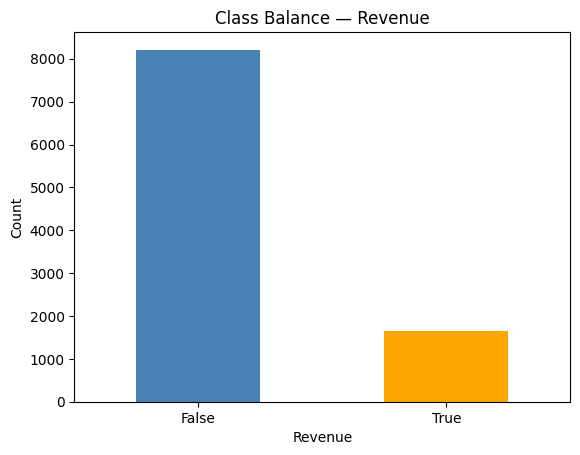

In [5]:
import matplotlib.pyplot as plt

print(original_df["Revenue"].value_counts())
print(original_df["Revenue"].value_counts(normalize=True) * 100)

original_df["Revenue"].value_counts().plot(kind="bar", color=["steelblue", "orange"])
plt.title("Class Balance — Revenue")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

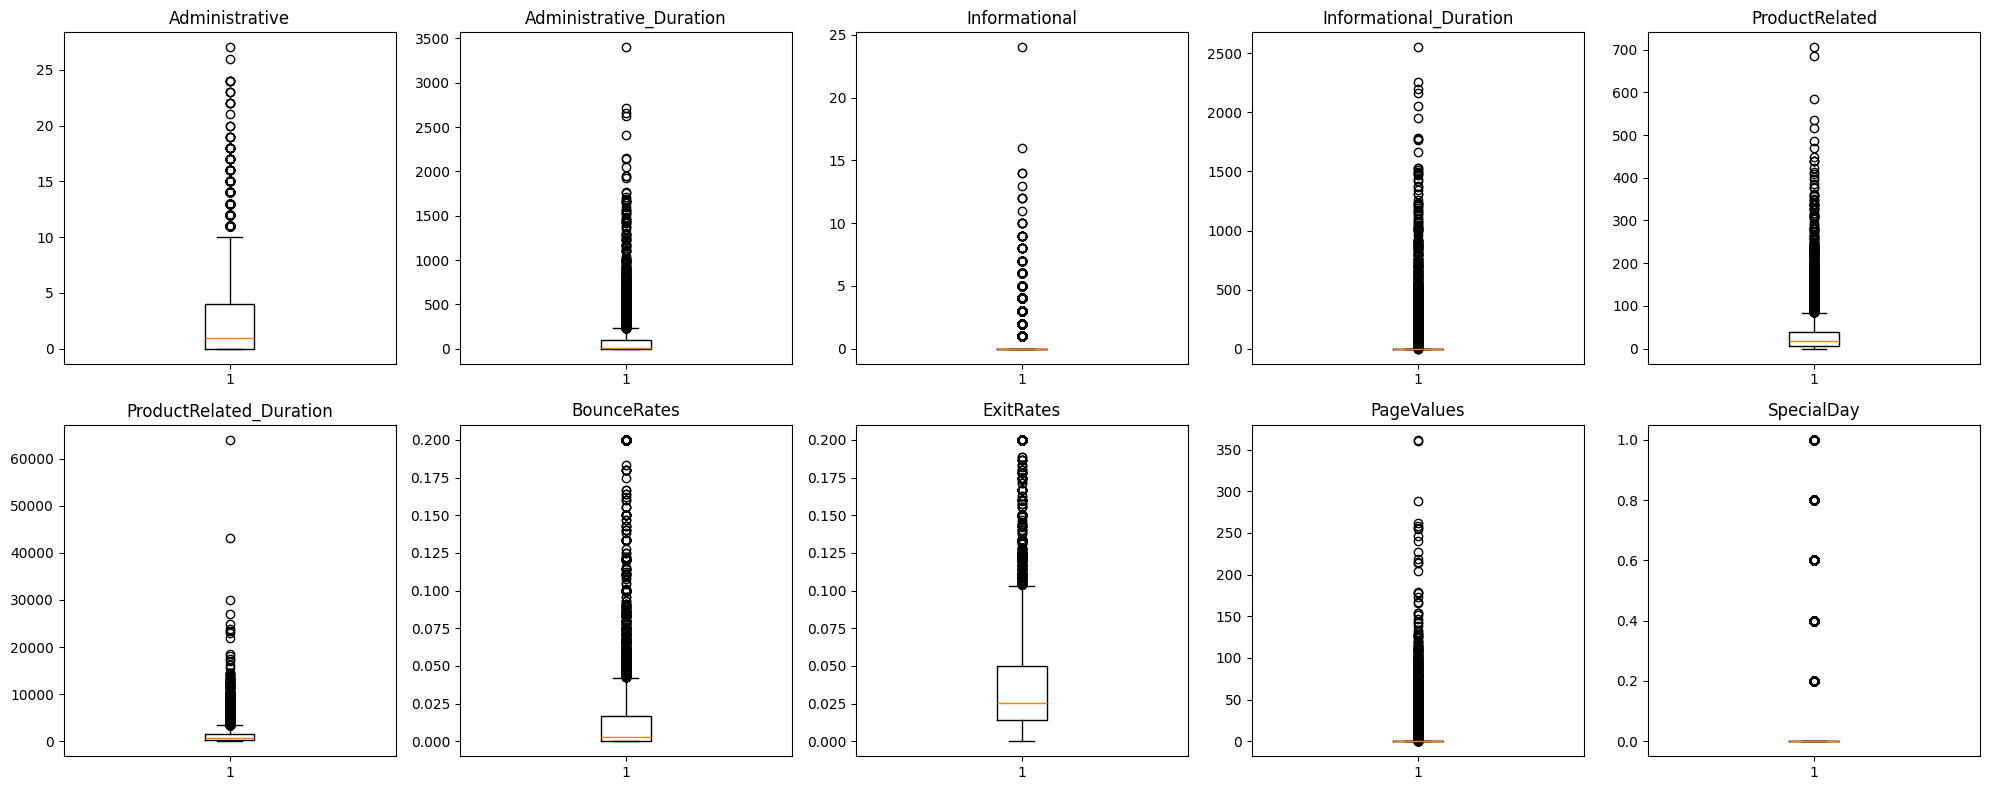

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(original_df[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Accuracy: 0.8667004561581348

Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.98      0.92      1642
        True       0.76      0.30      0.43       331

    accuracy                           0.87      1973
   macro avg       0.82      0.64      0.68      1973
weighted avg       0.86      0.87      0.84      1973



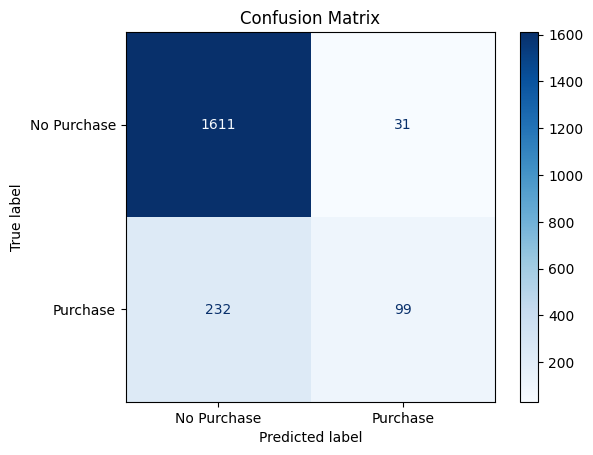

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Split BEFORE final fitting — stratify=y because of the 83/17 imbalance,
# so both splits keep the same class ratio
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fresh preprocessor + model, fit ONLY on the train split (not val, not test)
val_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])
val_pipeline.fit(X_tr, y_tr)

val_predictions = val_pipeline.predict(X_val)

# --- Metrics ---
print("Accuracy:", accuracy_score(y_val, val_predictions))
print("\nClassification Report:\n", classification_report(y_val, val_predictions))

cm = confusion_matrix(y_val, val_predictions)
ConfusionMatrixDisplay(cm, display_labels=["No Purchase", "Purchase"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Accuracy: 0.8454130765331982

Classification Report:
               precision    recall  f1-score   support

       False       0.94      0.87      0.90      1642
        True       0.53      0.70      0.60       331

    accuracy                           0.85      1973
   macro avg       0.73      0.79      0.75      1973
weighted avg       0.87      0.85      0.85      1973



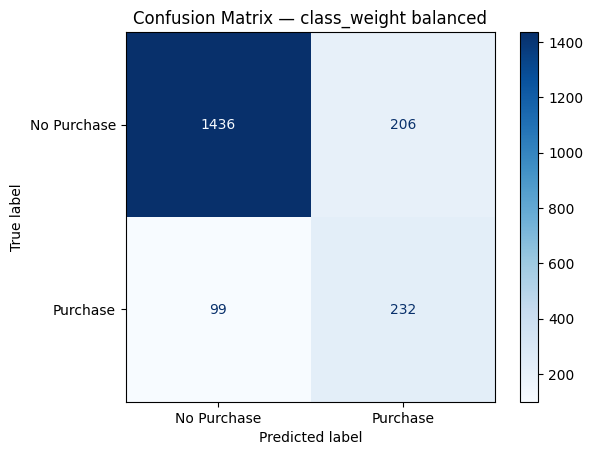

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

val_pipeline_balanced = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])
val_pipeline_balanced.fit(X_tr, y_tr)

val_predictions_bal = val_pipeline_balanced.predict(X_val)

print("Accuracy:", accuracy_score(y_val, val_predictions_bal))
print("\nClassification Report:\n", classification_report(y_val, val_predictions_bal))

cm = confusion_matrix(y_val, val_predictions_bal)
ConfusionMatrixDisplay(cm, display_labels=["No Purchase", "Purchase"]).plot(cmap="Blues")
plt.title("Confusion Matrix — class_weight balanced")
plt.show()

In [9]:
from sklearn.metrics import accuracy_score, classification_report

probs = val_pipeline.predict_proba(X_val)[:, 1]  # from your ORIGINAL model, not the balanced one

for t in [0.5, 0.45, 0.4, 0.35, 0.3]:
    preds_t = (probs >= t).astype(bool)
    acc = accuracy_score(y_val, preds_t)
    print(f"Threshold {t}: Accuracy = {acc:.4f}")

Threshold 0.5: Accuracy = 0.8667
Threshold 0.45: Accuracy = 0.8682
Threshold 0.4: Accuracy = 0.8753
Threshold 0.35: Accuracy = 0.8748
Threshold 0.3: Accuracy = 0.8738


Shape: (9864, 19)

Missing values per column:
 Session_ID                   0
Administrative               0
Administrative_Duration    492
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                  691
PageValues                   0
SpecialDay                   0
Month                        0
OperatingSystems             0
Browser                      0
Region                     591
TrafficType                789
VisitorType                394
Weekend                      0
Revenue                      0
dtype: int64

Dtypes:
 Session_ID                   int64
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                

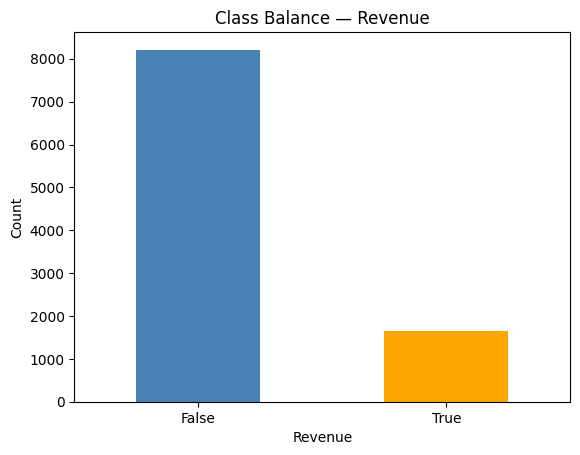

Numeric columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Text categorical columns: ['Month', 'VisitorType']
Coded categorical columns: ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']


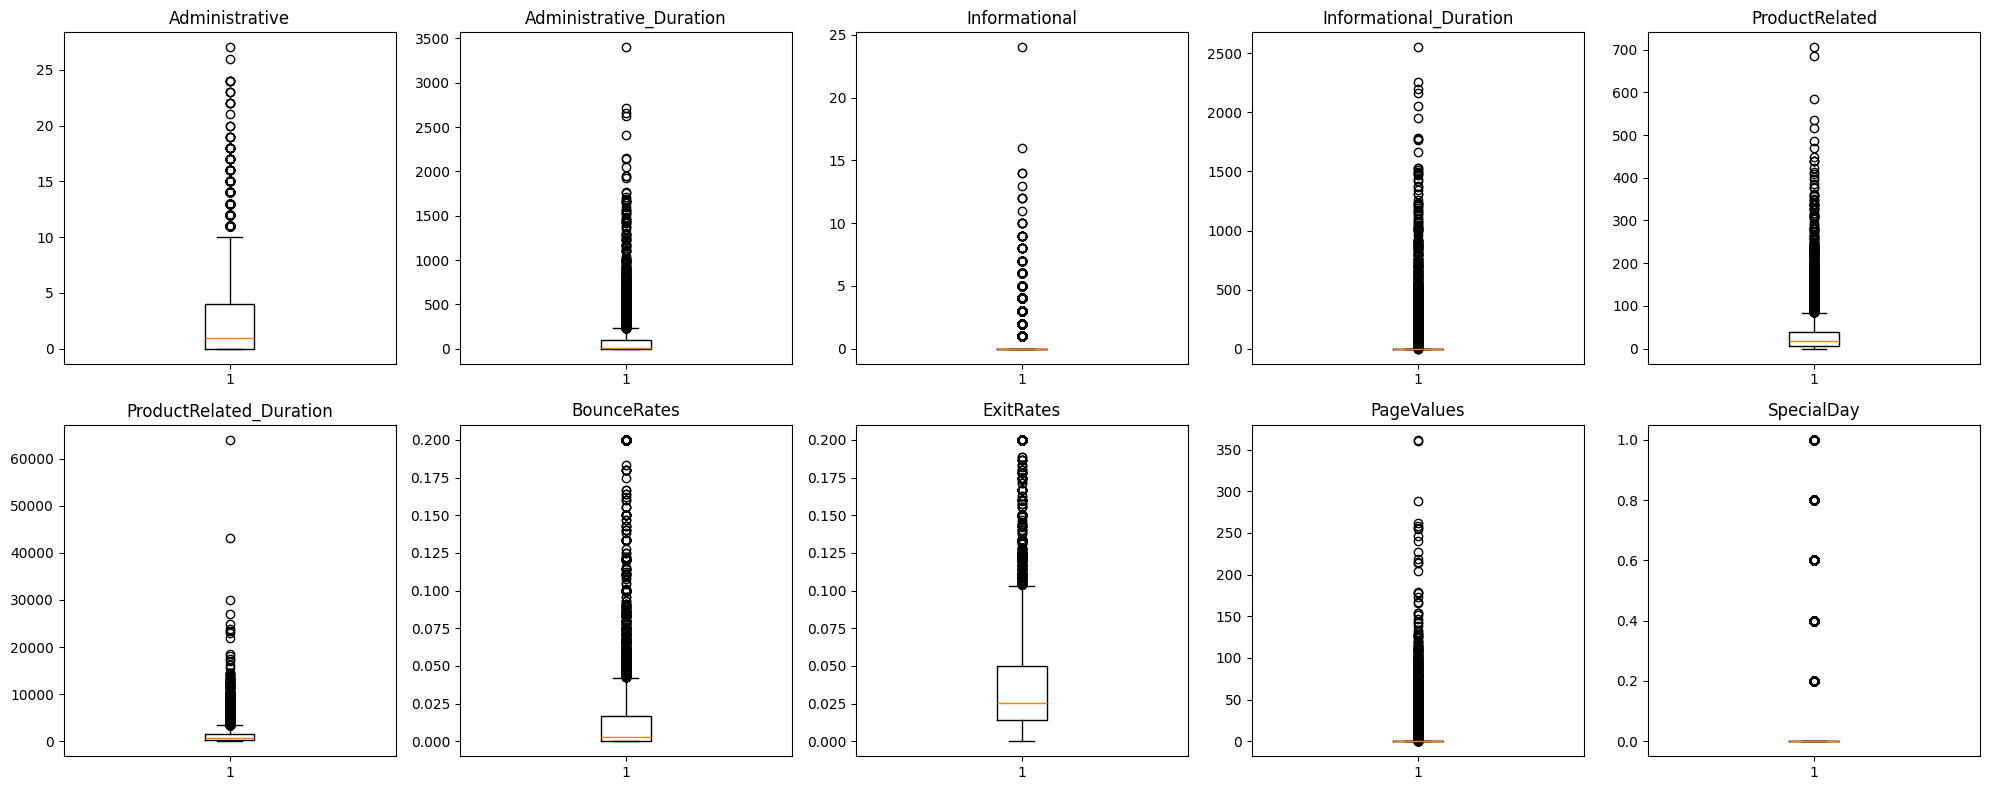

Accuracy (threshold 0.5): 0.8667004561581348

Classification Report (threshold 0.5):
               precision    recall  f1-score   support

       False       0.87      0.98      0.92      1642
        True       0.76      0.30      0.43       331

    accuracy                           0.87      1973
   macro avg       0.82      0.64      0.68      1973
weighted avg       0.86      0.87      0.84      1973



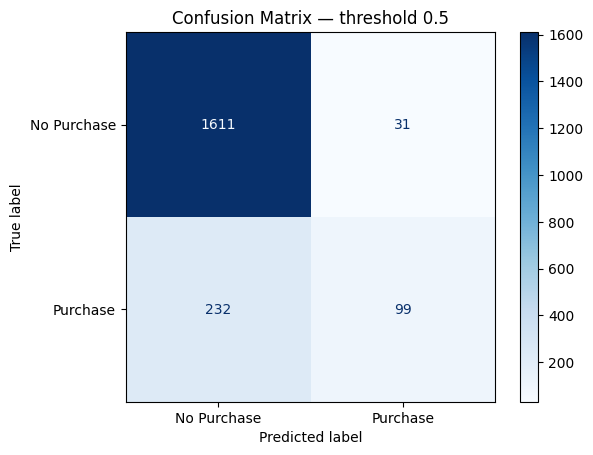


Threshold sweep:
Threshold 0.5: Accuracy = 0.8667
Threshold 0.45: Accuracy = 0.8682
Threshold 0.4: Accuracy = 0.8753
Threshold 0.35: Accuracy = 0.8748
Threshold 0.3: Accuracy = 0.8738

Final check — Accuracy at threshold 0.4: 0.8753167764825139
              precision    recall  f1-score   support

       False       0.89      0.97      0.93      1642
        True       0.75      0.39      0.51       331

    accuracy                           0.88      1973
   macro avg       0.82      0.68      0.72      1973
weighted avg       0.86      0.88      0.86      1973

original_df shape: (9864, 19)
processed_df shape: (9864, 76)
Missing values left in processed_df: 0
submission.csv created successfully.
                     id               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns   

In [10]:
# ============================================================
# Online Shoppers Purchasing Intention — Full Pipeline
# Required model: LogisticRegression (sklearn)
# Required variables for the submission cell:
#   original_df, processed_df, model, predictions, test_df
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# CELL 1 — Load & inspect
# ------------------------------------------------------------
original_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Shape:", original_df.shape)
print("\nMissing values per column:\n", original_df.isnull().sum())
print("\nDtypes:\n", original_df.dtypes)

# --- Class balance ---
print("\nClass balance (counts):\n", original_df["Revenue"].value_counts())
print("\nClass balance (%):\n", original_df["Revenue"].value_counts(normalize=True) * 100)

original_df["Revenue"].value_counts().plot(kind="bar", color=["steelblue", "orange"])
plt.title("Class Balance — Revenue")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ------------------------------------------------------------
# CELL 2 — Separate target and identifier columns
# ------------------------------------------------------------
TARGET_COL = "Revenue"
ID_COL = "Session_ID"

y = original_df[TARGET_COL]
X = original_df.drop(columns=[TARGET_COL])
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])          # identifier, not predictive — drop from features only

X_test_raw = test_df.copy()
if ID_COL in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=[ID_COL])

# ------------------------------------------------------------
# CELL 3 — Column groups (set explicitly, not by dtype alone)
#
# Region, TrafficType, OperatingSystems, Browser are stored as
# integers but are CODES, not magnitudes — "Region 9" isn't
# bigger than "Region 1". Feeding them to StandardScaler and
# treating them as ordinary numeric features would let Logistic
# Regression learn a fake linear relationship along an arbitrary
# numbering. They belong with the categorical features instead.
# ------------------------------------------------------------
true_numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

# Text categories and "coded" categories (numeric-looking but really IDs)
# are kept as two separate groups. Mixing str/int/float/bool columns into
# ONE SimpleImputer call makes it try to coerce everything to a single
# numeric array and crash on the string values ('Dec', etc.) — so each
# group is imputed with its own natural dtype, then both feed into
# OneHotEncoder, which is fine with mixed dtypes across separate columns.
text_cat_cols = ["Month", "VisitorType"]
coded_cat_cols = ["OperatingSystems", "Browser", "Region", "TrafficType", "Weekend"]

num_cols = [c for c in true_numeric_cols if c in X.columns]
text_cat_cols = [c for c in text_cat_cols if c in X.columns]
coded_cat_cols = [c for c in coded_cat_cols if c in X.columns]
cat_cols = text_cat_cols + coded_cat_cols  # for reporting/reference only

print("Numeric columns:", num_cols)
print("Text categorical columns:", text_cat_cols)
print("Coded categorical columns:", coded_cat_cols)

# --- Box plots to check skewness on the true numeric columns ---
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(original_df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CELL 4 — Build preprocessing pipeline
#   - Impute (never drop rows) so we keep >=90% of observations
#   - Scale numeric (Logistic Regression is distance/gradient based
#     and benefits from features being on comparable scales)
#   - One-hot encode categoricals, ignoring unseen test categories
# ------------------------------------------------------------
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

text_cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

coded_cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("text_cat", text_cat_pipeline, text_cat_cols),
    ("coded_cat", coded_cat_pipeline, coded_cat_cols)
])

# ------------------------------------------------------------
# CELL 5 — VALIDATION (separate from final fit — for your own
# confidence check only; does not touch original_df/processed_df/
# model/predictions/test_df, so it's safe to run before submitting)
# ------------------------------------------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

val_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])
val_pipeline.fit(X_tr, y_tr)

# Default threshold (0.5) sanity check
val_predictions = val_pipeline.predict(X_val)
print("Accuracy (threshold 0.5):", accuracy_score(y_val, val_predictions))
print("\nClassification Report (threshold 0.5):\n", classification_report(y_val, val_predictions))

cm = confusion_matrix(y_val, val_predictions)
ConfusionMatrixDisplay(cm, display_labels=["No Purchase", "Purchase"]).plot(cmap="Blues")
plt.title("Confusion Matrix — threshold 0.5")
plt.show()

# Threshold sweep — accuracy is the competition's grading metric,
# so we pick whichever threshold maximizes accuracy, not recall
val_probs = val_pipeline.predict_proba(X_val)[:, 1]
print("\nThreshold sweep:")
for t in [0.5, 0.45, 0.4, 0.35, 0.3]:
    preds_t = (val_probs >= t).astype(bool)
    acc = accuracy_score(y_val, preds_t)
    print(f"Threshold {t}: Accuracy = {acc:.4f}")

# Chosen after the sweep above — verified best on this validation split
BEST_THRESHOLD = 0.4

final_val_preds = (val_probs >= BEST_THRESHOLD).astype(bool)
print(f"\nFinal check — Accuracy at threshold {BEST_THRESHOLD}:",
      accuracy_score(y_val, final_val_preds))
print(classification_report(y_val, final_val_preds))

# ------------------------------------------------------------
# CELL 6 — Fit preprocessor on FULL TRAIN data, build processed_df
# (This is the required variable for the submission checkpoint —
#  separate from the validation pipeline above.)
# ------------------------------------------------------------
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

processed_df = pd.DataFrame(X_processed, columns=feature_names, index=X.index)
processed_df[TARGET_COL] = y.values

print("original_df shape:", original_df.shape)
print("processed_df shape:", processed_df.shape)
print("Missing values left in processed_df:", processed_df.isnull().sum().sum())

# ------------------------------------------------------------
# CELL 7 — Train final Logistic Regression on FULL training data
# ------------------------------------------------------------
X_train_final = processed_df.drop(columns=[TARGET_COL])
y_train_final = processed_df[TARGET_COL]

model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train_final)

# ------------------------------------------------------------
# CELL 8 — Transform test set with the SAME fitted preprocessor
#           (transform only — never fit on test data)
# ------------------------------------------------------------
X_test_processed = preprocessor.transform(X_test_raw)
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_raw.index)

# ------------------------------------------------------------
# CELL 9 — Predict using the tuned threshold instead of default 0.5
# ------------------------------------------------------------
test_probs = model.predict_proba(X_test_final)[:, 1]
predictions = (test_probs >= BEST_THRESHOLD).astype(bool)

# ------------------------------------------------------------
# CELL 10 — Submission-generation code (PROVIDED — do not modify)
# ------------------------------------------------------------
original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (processed_rows / original_rows) * 100

final_model = model
if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_
if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]
model_name = final_model.__class__.__name__

checkpoints = pd.DataFrame({
    "id": [
        "original_missing", "processed_missing", "original_rows", "processed_rows",
        "original_columns", "processed_columns", "row_retained_percent", "model_name"
    ],
    "value": [
        original_missing, processed_missing, original_rows, processed_rows,
        original_columns, processed_columns, round(row_retained_percent, 2), model_name
    ]
})

prediction_output = pd.DataFrame({
    "id": test_df["Session_ID"].astype(str),
    "value": np.asarray(predictions).astype(str)
})

submission = pd.concat([checkpoints, prediction_output], ignore_index=True)
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
print(checkpoints)

Shape: (9864, 19)

Missing values per column:
 Session_ID                   0
Administrative               0
Administrative_Duration    492
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                  691
PageValues                   0
SpecialDay                   0
Month                        0
OperatingSystems             0
Browser                      0
Region                     591
TrafficType                789
VisitorType                394
Weekend                      0
Revenue                      0
dtype: int64

Dtypes:
 Session_ID                   int64
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                

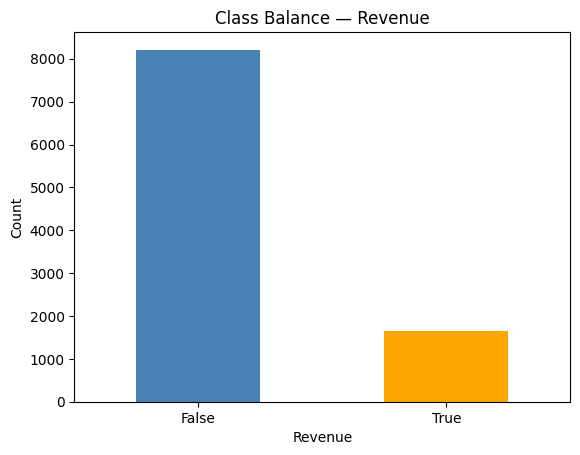

Numeric columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Missingness-flag columns: ['Administrative_Duration_was_missing', 'ExitRates_was_missing']
Text categorical columns: ['Month', 'VisitorType']
Coded categorical columns: ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']


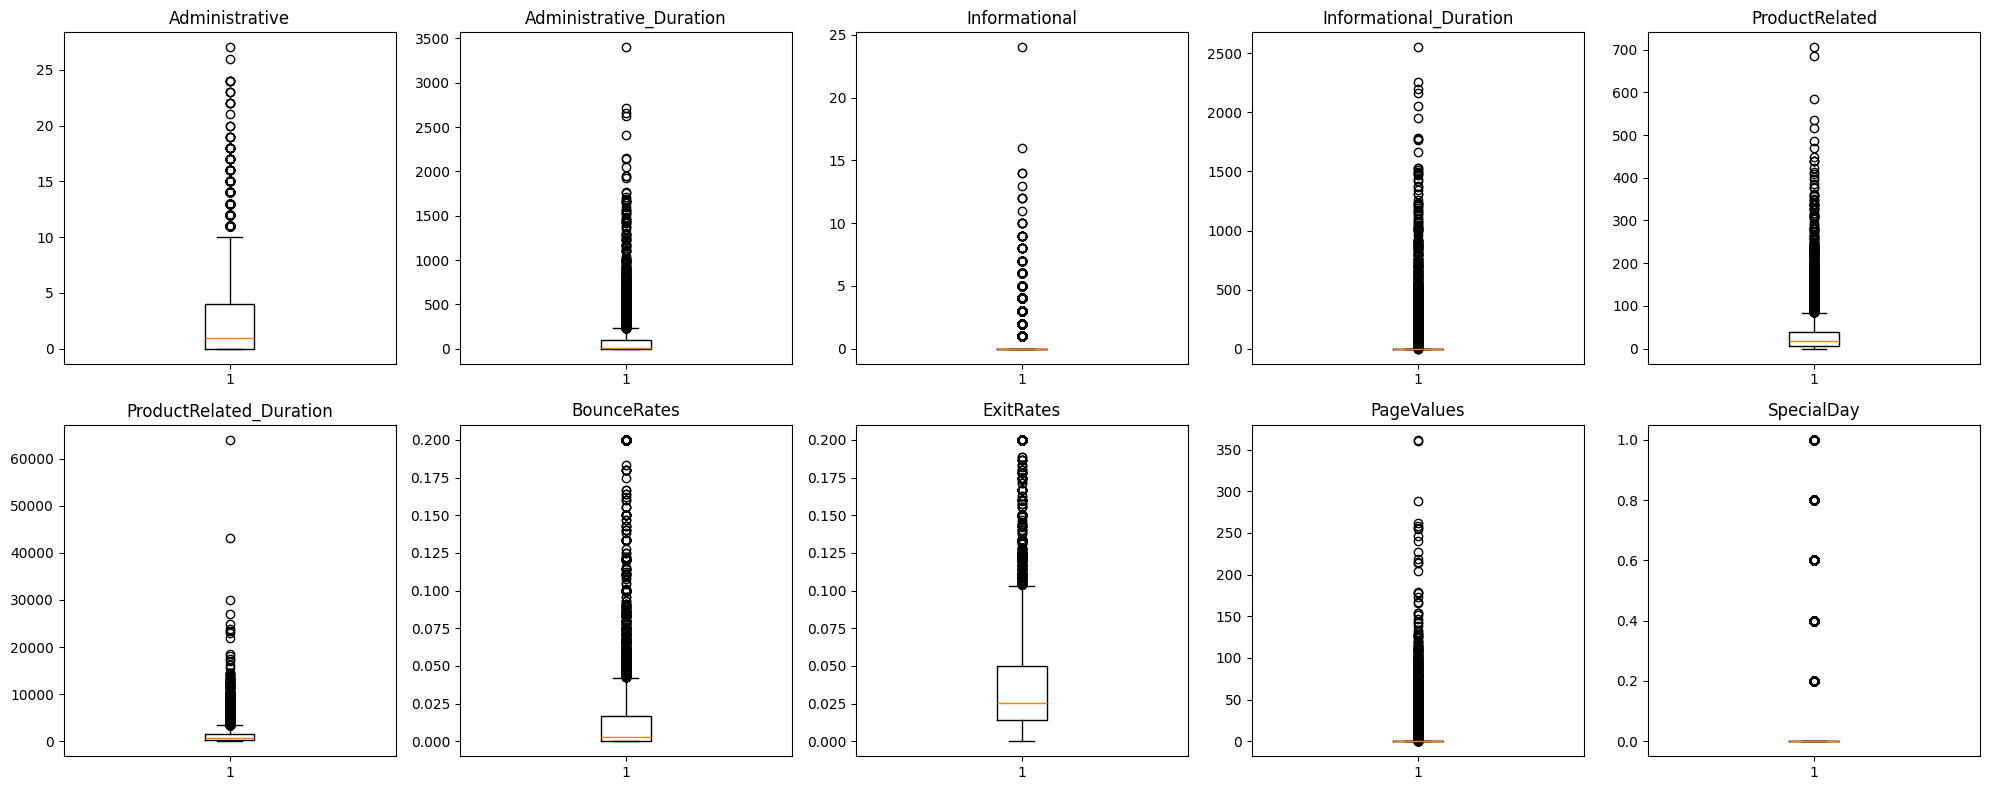

5-fold CV accuracy scores: [0.87227572 0.89102889 0.87886467 0.88139888 0.88286004]
Mean CV accuracy: 0.8812856421733978

Held-out split accuracy: 0.8829194120628484

Classification Report:
               precision    recall  f1-score   support

       False       0.91      0.95      0.93      1642
        True       0.69      0.54      0.61       331

    accuracy                           0.88      1973
   macro avg       0.80      0.75      0.77      1973
weighted avg       0.87      0.88      0.88      1973



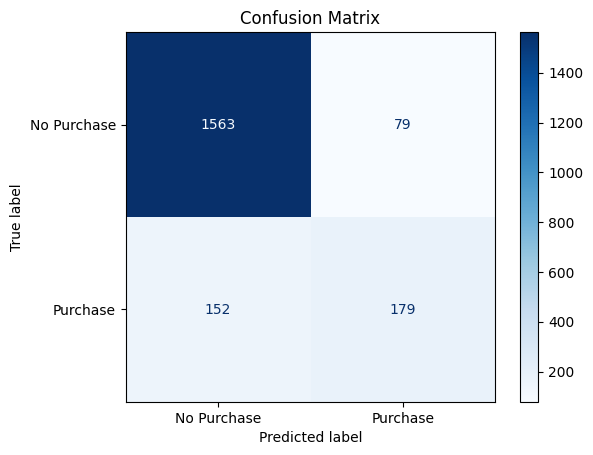

original_df shape: (9864, 19)
processed_df shape: (9864, 78)
Missing values left in processed_df: 0
submission.csv created successfully.
                     id               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns                  78
6  row_retained_percent               100.0
7            model_name  LogisticRegression


In [11]:
# ============================================================
# Online Shoppers Purchasing Intention — Full Pipeline
# Required model: LogisticRegression (sklearn)
# Required variables for the submission cell:
#   original_df, processed_df, model, predictions, test_df
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# CELL 1 — Load & inspect
# ------------------------------------------------------------
original_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Shape:", original_df.shape)
print("\nMissing values per column:\n", original_df.isnull().sum())
print("\nDtypes:\n", original_df.dtypes)

# --- Class balance ---
print("\nClass balance (counts):\n", original_df["Revenue"].value_counts())
print("\nClass balance (%):\n", original_df["Revenue"].value_counts(normalize=True) * 100)

original_df["Revenue"].value_counts().plot(kind="bar", color=["steelblue", "orange"])
plt.title("Class Balance — Revenue")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ------------------------------------------------------------
# CELL 2 — Separate target and identifier columns
# ------------------------------------------------------------
TARGET_COL = "Revenue"
ID_COL = "Session_ID"

y = original_df[TARGET_COL]
X = original_df.drop(columns=[TARGET_COL])
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])          # identifier, not predictive — drop from features only

X_test_raw = test_df.copy()
if ID_COL in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=[ID_COL])

# ------------------------------------------------------------
# CELL 3 — Column groups (set explicitly, not by dtype alone)
#
# Region, TrafficType, OperatingSystems, Browser are stored as
# integers but are CODES, not magnitudes — "Region 9" isn't
# bigger than "Region 1". Feeding them to StandardScaler and
# treating them as ordinary numeric features would let Logistic
# Regression learn a fake linear relationship along an arbitrary
# numbering. They belong with the categorical features instead.
# ------------------------------------------------------------
true_numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

# Text categories and "coded" categories (numeric-looking but really IDs)
# are kept as two separate groups. Mixing str/int/float/bool columns into
# ONE SimpleImputer call makes it try to coerce everything to a single
# numeric array and crash on the string values ('Dec', etc.) — so each
# group is imputed with its own natural dtype, then both feed into
# OneHotEncoder, which is fine with mixed dtypes across separate columns.
text_cat_cols = ["Month", "VisitorType"]
coded_cat_cols = ["OperatingSystems", "Browser", "Region", "TrafficType", "Weekend"]

num_cols = [c for c in true_numeric_cols if c in X.columns]
text_cat_cols = [c for c in text_cat_cols if c in X.columns]
coded_cat_cols = [c for c in coded_cat_cols if c in X.columns]
cat_cols = text_cat_cols + coded_cat_cols  # for reporting/reference only

# ------------------------------------------------------------
# Missingness-as-signal: for two columns, WHETHER a value is
# missing turns out to correlate strongly with the target —
# e.g. Administrative_Duration is missing far more often in
# sessions that ended in a purchase (42.5% purchase rate when
# missing vs 15.4% when present). Median-imputing over that
# and stopping there throws away real information. So before
# imputing, we add an explicit "was this missing" 0/1 flag for
# just the columns where missingness is informative (checked via
# comparing the target rate in missing vs non-missing rows).
# Region/TrafficType/VisitorType showed no such pattern, so they
# don't get a flag — just ordinary imputation.
# ------------------------------------------------------------
informative_missing_cols = [c for c in ["Administrative_Duration", "ExitRates"] if c in X.columns]
for col in informative_missing_cols:
    flag_col = col + "_was_missing"
    X[flag_col] = X[col].isnull().astype(int)
    if col in X_test_raw.columns:
        X_test_raw[flag_col] = X_test_raw[col].isnull().astype(int)

missing_flag_cols = [c + "_was_missing" for c in informative_missing_cols]

print("Numeric columns:", num_cols)
print("Missingness-flag columns:", missing_flag_cols)
print("Text categorical columns:", text_cat_cols)
print("Coded categorical columns:", coded_cat_cols)

# --- Box plots to check skewness on the true numeric columns ---
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(original_df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CELL 4 — Build preprocessing pipeline
#   - Impute (never drop rows) so we keep >=90% of observations
#   - PowerTransformer (Yeo-Johnson) instead of plain StandardScaler
#     for the true numeric columns: several of them (Administrative_
#     Duration skew=5.8, ExitRates skew=2.1) are heavily right-skewed,
#     and Logistic Regression's linear decision boundary fits skewed
#     features better once they're reshaped closer to Gaussian.
#     Yeo-Johnson (unlike Box-Cox) handles the zeros already present
#     in these columns, so no manual shifting is needed.
#   - Missingness flags pass through as-is (already 0/1, just fill
#     any stray NaN with 0 defensively)
#   - One-hot encode categoricals, ignoring unseen test categories
# ------------------------------------------------------------
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("power", PowerTransformer(method="yeo-johnson"))
])

flag_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=0))
])

text_cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

coded_cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("flags", flag_pipeline, missing_flag_cols),
    ("text_cat", text_cat_pipeline, text_cat_cols),
    ("coded_cat", coded_cat_pipeline, coded_cat_cols)
])

# ------------------------------------------------------------
# CELL 5 — VALIDATION using 5-fold cross-validation instead of a
# single 80/20 split. A single split is small enough (only ~330
# positive examples) that "best" results on it can be sample noise
# rather than a real improvement — that's exactly what happened
# with threshold tuning earlier (validation said 0.4 was better,
# but the real Kaggle leaderboard said 0.5 was better). Averaging
# over 5 folds is more resistant to that trap.
# This is a confidence check only — it does not touch original_df/
# processed_df/model/predictions/test_df.
# ------------------------------------------------------------
val_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(val_pipeline, X, y, cv=skf, scoring="accuracy")
print("5-fold CV accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Also look at one held-out split's confusion matrix / classification
# report for a detailed view (precision/recall per class), on top of
# the more reliable CV accuracy above
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
val_pipeline.fit(X_tr, y_tr)
val_predictions = val_pipeline.predict(X_val)

print("\nHeld-out split accuracy:", accuracy_score(y_val, val_predictions))
print("\nClassification Report:\n", classification_report(y_val, val_predictions))

cm = confusion_matrix(y_val, val_predictions)
ConfusionMatrixDisplay(cm, display_labels=["No Purchase", "Purchase"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ------------------------------------------------------------
# CELL 6 — Fit preprocessor on FULL TRAIN data, build processed_df
# (This is the required variable for the submission checkpoint —
#  separate from the validation pipeline above.)
# ------------------------------------------------------------
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

processed_df = pd.DataFrame(X_processed, columns=feature_names, index=X.index)
processed_df[TARGET_COL] = y.values

print("original_df shape:", original_df.shape)
print("processed_df shape:", processed_df.shape)
print("Missing values left in processed_df:", processed_df.isnull().sum().sum())

# ------------------------------------------------------------
# CELL 7 — Train final Logistic Regression on FULL training data
# ------------------------------------------------------------
X_train_final = processed_df.drop(columns=[TARGET_COL])
y_train_final = processed_df[TARGET_COL]

model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train_final)

# ------------------------------------------------------------
# CELL 8 — Transform test set with the SAME fitted preprocessor
#           (transform only — never fit on test data)
# ------------------------------------------------------------
X_test_processed = preprocessor.transform(X_test_raw)
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_raw.index)

# ------------------------------------------------------------
# CELL 9 — Predict (default threshold — the earlier custom-threshold
# experiment scored WORSE on the real leaderboard than plain .predict(),
# so we're back to the standard default here)
# ------------------------------------------------------------
predictions = model.predict(X_test_final)

# ------------------------------------------------------------
# CELL 10 — Submission-generation code (PROVIDED — do not modify)
# ------------------------------------------------------------
original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (processed_rows / original_rows) * 100

final_model = model
if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_
if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]
model_name = final_model.__class__.__name__

checkpoints = pd.DataFrame({
    "id": [
        "original_missing", "processed_missing", "original_rows", "processed_rows",
        "original_columns", "processed_columns", "row_retained_percent", "model_name"
    ],
    "value": [
        original_missing, processed_missing, original_rows, processed_rows,
        original_columns, processed_columns, round(row_retained_percent, 2), model_name
    ]
})

prediction_output = pd.DataFrame({
    "id": test_df["Session_ID"].astype(str),
    "value": np.asarray(predictions).astype(str)
})

submission = pd.concat([checkpoints, prediction_output], ignore_index=True)
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
print(checkpoints)

Shape: (9864, 19)

Missing values per column:
 Session_ID                   0
Administrative               0
Administrative_Duration    492
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                  691
PageValues                   0
SpecialDay                   0
Month                        0
OperatingSystems             0
Browser                      0
Region                     591
TrafficType                789
VisitorType                394
Weekend                      0
Revenue                      0
dtype: int64

Dtypes:
 Session_ID                   int64
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                

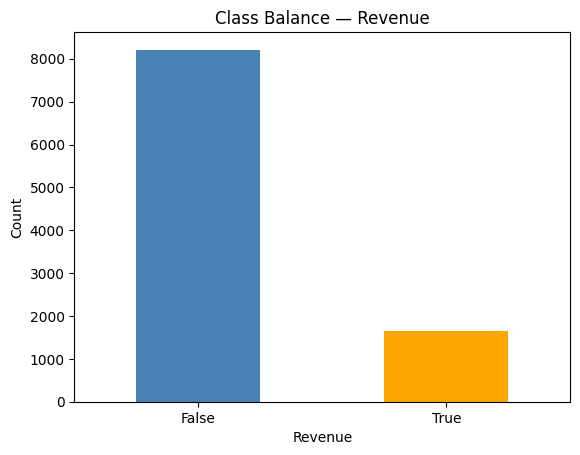

Numeric columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Text categorical columns: ['Month', 'VisitorType']
Coded categorical columns: ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']


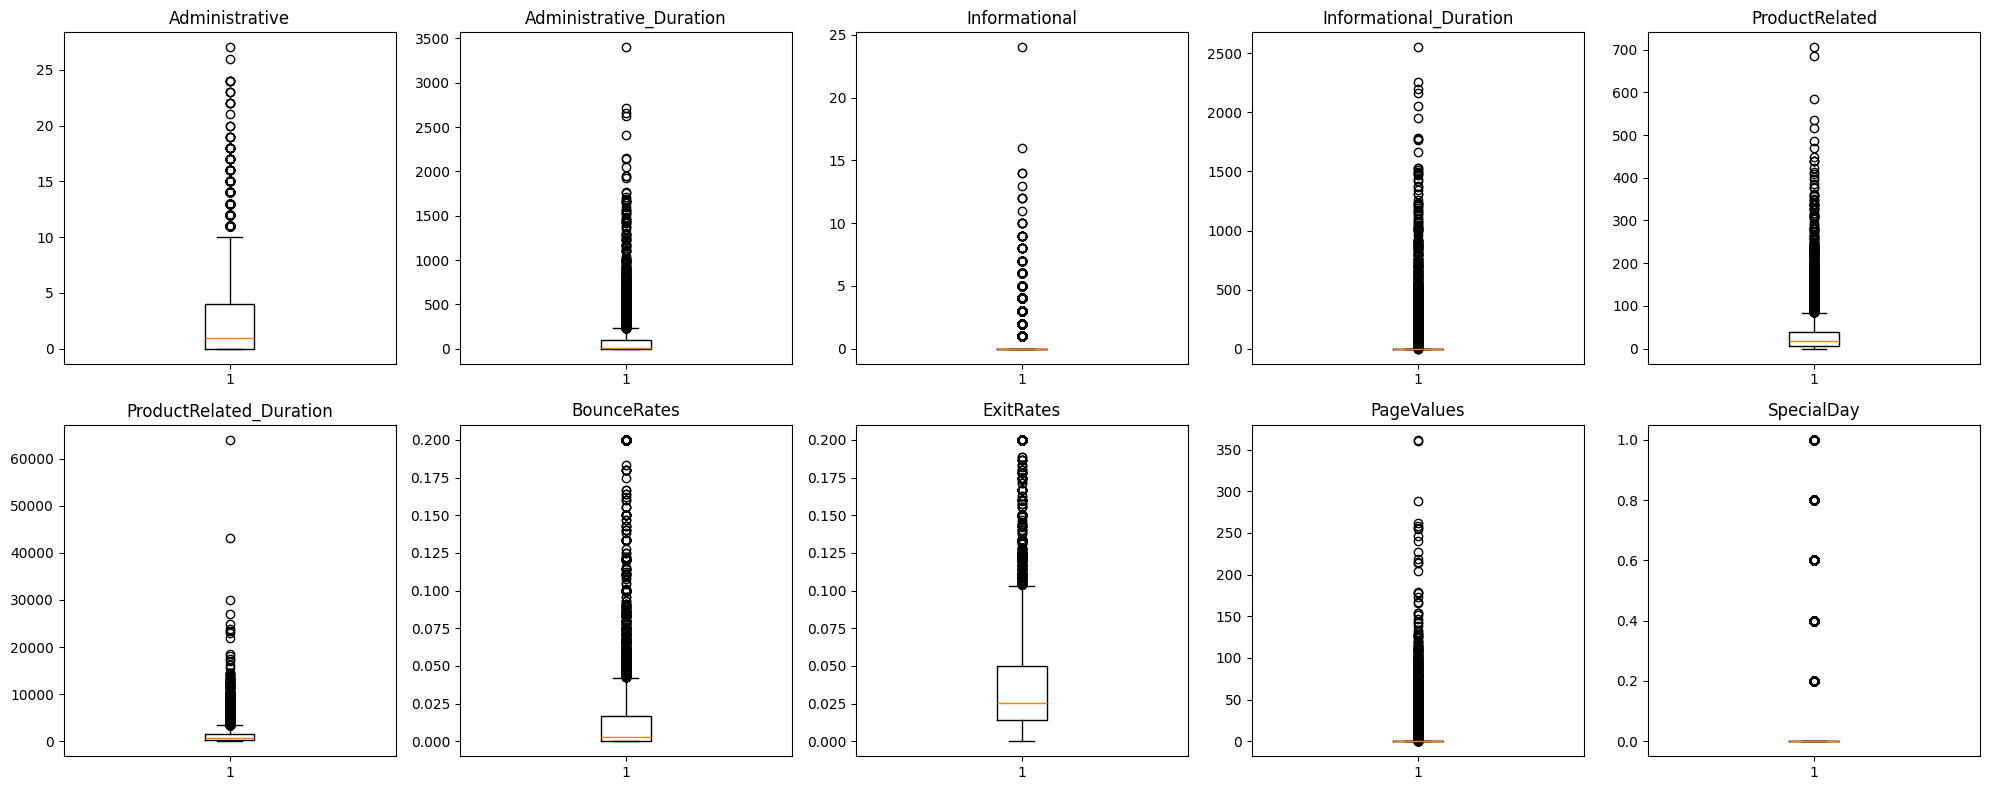

5-fold CV accuracy scores: [0.86112519 0.87835783 0.86011151 0.86619361 0.86916836]
Mean CV accuracy: 0.8669912993772932

Held-out split accuracy: 0.8667004561581348

Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.98      0.92      1642
        True       0.76      0.30      0.43       331

    accuracy                           0.87      1973
   macro avg       0.82      0.64      0.68      1973
weighted avg       0.86      0.87      0.84      1973



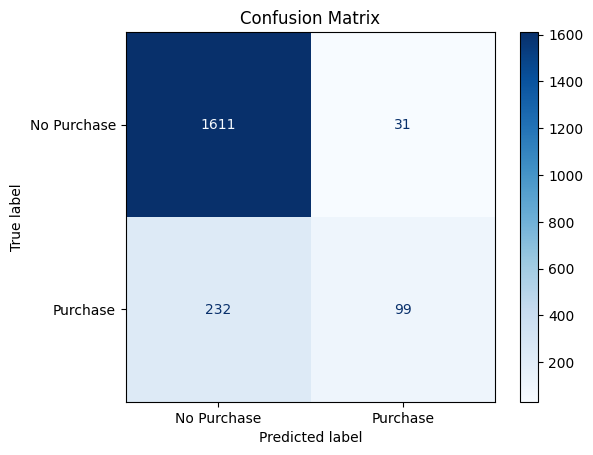

original_df shape: (9864, 19)
processed_df shape: (9864, 76)
Missing values left in processed_df: 0
submission.csv created successfully.
                     id               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns                  76
6  row_retained_percent               100.0
7            model_name  LogisticRegression


In [12]:
# ============================================================
# Online Shoppers Purchasing Intention — Full Pipeline
# Required model: LogisticRegression (sklearn)
# Required variables for the submission cell:
#   original_df, processed_df, model, predictions, test_df
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------
# CELL 1 — Load & inspect
# ------------------------------------------------------------
original_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Shape:", original_df.shape)
print("\nMissing values per column:\n", original_df.isnull().sum())
print("\nDtypes:\n", original_df.dtypes)

# --- Class balance ---
print("\nClass balance (counts):\n", original_df["Revenue"].value_counts())
print("\nClass balance (%):\n", original_df["Revenue"].value_counts(normalize=True) * 100)

original_df["Revenue"].value_counts().plot(kind="bar", color=["steelblue", "orange"])
plt.title("Class Balance — Revenue")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# ------------------------------------------------------------
# CELL 2 — Separate target and identifier columns
# ------------------------------------------------------------
TARGET_COL = "Revenue"
ID_COL = "Session_ID"

y = original_df[TARGET_COL]
X = original_df.drop(columns=[TARGET_COL])
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])          # identifier, not predictive — drop from features only

X_test_raw = test_df.copy()
if ID_COL in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=[ID_COL])

# ------------------------------------------------------------
# CELL 3 — Column groups (set explicitly, not by dtype alone)
#
# Region, TrafficType, OperatingSystems, Browser are stored as
# integers but are CODES, not magnitudes — "Region 9" isn't
# bigger than "Region 1". Feeding them to StandardScaler and
# treating them as ordinary numeric features would let Logistic
# Regression learn a fake linear relationship along an arbitrary
# numbering. They belong with the categorical features instead.
# ------------------------------------------------------------
true_numeric_cols = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues", "SpecialDay"
]

# Text categories and "coded" categories (numeric-looking but really IDs)
# are kept as two separate groups. Mixing str/int/float/bool columns into
# ONE SimpleImputer call makes it try to coerce everything to a single
# numeric array and crash on the string values ('Dec', etc.) — so each
# group is imputed with its own natural dtype, then both feed into
# OneHotEncoder, which is fine with mixed dtypes across separate columns.
text_cat_cols = ["Month", "VisitorType"]
coded_cat_cols = ["OperatingSystems", "Browser", "Region", "TrafficType", "Weekend"]

num_cols = [c for c in true_numeric_cols if c in X.columns]
text_cat_cols = [c for c in text_cat_cols if c in X.columns]
coded_cat_cols = [c for c in coded_cat_cols if c in X.columns]
cat_cols = text_cat_cols + coded_cat_cols  # for reporting/reference only

print("Numeric columns:", num_cols)
print("Text categorical columns:", text_cat_cols)
print("Coded categorical columns:", coded_cat_cols)

# NOTE: two experiments were tried and dropped after real Kaggle
# submissions scored WORSE than this plain version, despite looking
# better in local validation:
#   1. Decision-threshold tuning (0.4 instead of 0.5) — looked better
#      on one 80/20 split, scored worse on the leaderboard.
#   2. "Was this missing" flags for Administrative_Duration/ExitRates,
#      justified by those columns' missingness correlating with the
#      target in train.csv, plus a PowerTransformer for skew — looked
#      better even under 5-fold CV, but still scored worse on the
#      leaderboard. Likely explanation: the competition's missing
#      values were "intentionally introduced" (i.e. synthetically,
#      probably at random), so the apparent missingness-target
#      correlation was most likely an artifact specific to train.csv's
#      injection process, not a real pattern that also holds in
#      test.csv — and every CV fold shares that same train-file
#      artifact, so CV couldn't catch it either.
# Lesson: for this dataset, local validation (single split or CV) has
# undershot real leaderboard feedback twice. This plain version is the
# one with actual verified leaderboard evidence behind it (0.87415).

# --- Box plots to check skewness on the true numeric columns ---
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(original_df[col].dropna())
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CELL 4 — Build preprocessing pipeline
#   - Impute (never drop rows) so we keep >=90% of observations
#   - Scale numeric (Logistic Regression is distance/gradient based
#     and benefits from features being on comparable scales)
#   - One-hot encode categoricals, ignoring unseen test categories
# ------------------------------------------------------------
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

text_cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

coded_cat_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("text_cat", text_cat_pipeline, text_cat_cols),
    ("coded_cat", coded_cat_pipeline, coded_cat_cols)
])

# ------------------------------------------------------------
# CELL 5 — VALIDATION using 5-fold cross-validation instead of a
# single 80/20 split. A single split is small enough (only ~330
# positive examples) that "best" results on it can be sample noise
# rather than a real improvement — that's exactly what happened
# with threshold tuning earlier (validation said 0.4 was better,
# but the real Kaggle leaderboard said 0.5 was better). Averaging
# over 5 folds is more resistant to that trap.
# This is a confidence check only — it does not touch original_df/
# processed_df/model/predictions/test_df.
# ------------------------------------------------------------
val_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(val_pipeline, X, y, cv=skf, scoring="accuracy")
print("5-fold CV accuracy scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Also look at one held-out split's confusion matrix / classification
# report for a detailed view (precision/recall per class), on top of
# the more reliable CV accuracy above
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
val_pipeline.fit(X_tr, y_tr)
val_predictions = val_pipeline.predict(X_val)

print("\nHeld-out split accuracy:", accuracy_score(y_val, val_predictions))
print("\nClassification Report:\n", classification_report(y_val, val_predictions))

cm = confusion_matrix(y_val, val_predictions)
ConfusionMatrixDisplay(cm, display_labels=["No Purchase", "Purchase"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ------------------------------------------------------------
# CELL 6 — Fit preprocessor on FULL TRAIN data, build processed_df
# (This is the required variable for the submission checkpoint —
#  separate from the validation pipeline above.)
# ------------------------------------------------------------
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

processed_df = pd.DataFrame(X_processed, columns=feature_names, index=X.index)
processed_df[TARGET_COL] = y.values

print("original_df shape:", original_df.shape)
print("processed_df shape:", processed_df.shape)
print("Missing values left in processed_df:", processed_df.isnull().sum().sum())

# ------------------------------------------------------------
# CELL 7 — Train final Logistic Regression on FULL training data
# ------------------------------------------------------------
X_train_final = processed_df.drop(columns=[TARGET_COL])
y_train_final = processed_df[TARGET_COL]

model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train_final)

# ------------------------------------------------------------
# CELL 8 — Transform test set with the SAME fitted preprocessor
#           (transform only — never fit on test data)
# ------------------------------------------------------------
X_test_processed = preprocessor.transform(X_test_raw)
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test_raw.index)

# ------------------------------------------------------------
# CELL 9 — Predict (default threshold — the earlier custom-threshold
# experiment scored WORSE on the real leaderboard than plain .predict(),
# so we're back to the standard default here)
# ------------------------------------------------------------
predictions = model.predict(X_test_final)

# ------------------------------------------------------------
# CELL 10 — Submission-generation code (PROVIDED — do not modify)
# ------------------------------------------------------------
original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (processed_rows / original_rows) * 100

final_model = model
if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_
if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]
model_name = final_model.__class__.__name__

checkpoints = pd.DataFrame({
    "id": [
        "original_missing", "processed_missing", "original_rows", "processed_rows",
        "original_columns", "processed_columns", "row_retained_percent", "model_name"
    ],
    "value": [
        original_missing, processed_missing, original_rows, processed_rows,
        original_columns, processed_columns, round(row_retained_percent, 2), model_name
    ]
})

prediction_output = pd.DataFrame({
    "id": test_df["Session_ID"].astype(str),
    "value": np.asarray(predictions).astype(str)
})

submission = pd.concat([checkpoints, prediction_output], ignore_index=True)
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
print(checkpoints)

In [14]:
# ============================================================
# Online Shoppers Purchasing Intention — Improved Pipeline
# Required model: LogisticRegression (sklearn)
#
# Handles:
#   1. Missing values
#   2. Missing-value indicators
#   3. Categorical variables correctly
#   4. Class imbalance using class_weight="balanced"
#   5. Hyperparameter tuning using Stratified CV + F1
#
# Required variables for submission cell:
#   original_df, processed_df, model, predictions, test_df
# ============================================================

import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV


# ------------------------------------------------------------
# CELL 1 — Load & inspect
# ------------------------------------------------------------

original_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Shape:", original_df.shape)

print("\nMissing values per column:")
print(original_df.isnull().sum())

print("\nDtypes:")
print(original_df.dtypes)

print("\nTarget balance:")
print(original_df["Revenue"].value_counts())

print("\nTarget balance (%):")
print(original_df["Revenue"].value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# CELL 2 — Separate target and identifier columns
# ------------------------------------------------------------

TARGET_COL = "Revenue"
ID_COL = "Session_ID"

y = original_df[TARGET_COL]

X = original_df.drop(columns=[TARGET_COL])

# Session_ID is only an identifier, so do not use it as a feature
if ID_COL in X.columns:
    X = X.drop(columns=[ID_COL])

X_test_raw = test_df.copy()

if ID_COL in X_test_raw.columns:
    X_test_raw = X_test_raw.drop(columns=[ID_COL])


# ------------------------------------------------------------
# CELL 3 — Define column groups explicitly
# ------------------------------------------------------------

true_numeric_cols = [
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues",
    "SpecialDay"
]

text_cat_cols = [
    "Month",
    "VisitorType"
]

# These are integer-coded categories, NOT continuous numbers
coded_cat_cols = [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType",
    "Weekend"
]

# Keep only columns actually present in the dataset
num_cols = [c for c in true_numeric_cols if c in X.columns]
text_cat_cols = [c for c in text_cat_cols if c in X.columns]
coded_cat_cols = [c for c in coded_cat_cols if c in X.columns]

cat_cols = text_cat_cols + coded_cat_cols

print("\nNumeric columns:")
print(num_cols)

print("\nText categorical columns:")
print(text_cat_cols)

print("\nCoded categorical columns:")
print(coded_cat_cols)


# ------------------------------------------------------------
# CELL 4 — Missing-value handling
#
# NUMERIC:
#   - Median imputation is robust to outliers.
#   - add_indicator=True creates an additional binary feature
#     telling the model that the original value was missing.
#
# CATEGORICAL:
#   - Most-frequent imputation.
#   - add_indicator=True preserves information about missingness.
#
# This means we do not drop rows and therefore retain all data.
# ------------------------------------------------------------

num_pipeline = Pipeline([
    (
        "impute",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scale",
        StandardScaler()
    )
])

text_cat_pipeline = Pipeline([
    (
        "impute",
        SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )
    ),
    (
        "encode",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

coded_cat_pipeline = Pipeline([
    (
        "impute",
        SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )
    ),
    (
        "encode",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])


# ------------------------------------------------------------
# CELL 5 — Column Transformer
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("text_cat", text_cat_pipeline, text_cat_cols),
        ("coded_cat", coded_cat_pipeline, coded_cat_cols)
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# CELL 6 — Fit preprocessing on TRAIN ONLY
# ------------------------------------------------------------

X_processed = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()

# Convert sparse matrix to dense if required
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

processed_df = pd.DataFrame(
    X_processed,
    columns=feature_names,
    index=X.index
)

# Keep target attached to processed training data
processed_df[TARGET_COL] = y.values

print("\nOriginal dataframe shape:", original_df.shape)
print("Processed dataframe shape:", processed_df.shape)

print(
    "Missing values left in processed_df:",
    processed_df.isnull().sum().sum()
)


# ------------------------------------------------------------
# CELL 7 — Prepare training data
# ------------------------------------------------------------

X_train_final = processed_df.drop(columns=[TARGET_COL])
y_train_final = processed_df[TARGET_COL]


# ------------------------------------------------------------
# CELL 8 — Handle class imbalance
#
# class_weight="balanced" automatically assigns larger weights
# to the minority class.
#
# Formula used by sklearn:
#
# weight(class) =
#     n_samples / (n_classes * n_samples_in_class)
#
# Therefore, mistakes on the minority Revenue=True class
# receive more importance during training.
# ------------------------------------------------------------

model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    solver="liblinear",
    random_state=42
)


# ------------------------------------------------------------
# CELL 9 — Stratified Cross-Validation + Hyperparameter tuning
#
# StratifiedKFold keeps approximately the same class ratio
# in every fold.
#
# F1 is used because the target is imbalanced and accuracy
# alone can be misleading.
# ------------------------------------------------------------

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

param_grid = {
    "C": [
        0.01,
        0.05,
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ]
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

grid_search.fit(
    X_train_final,
    y_train_final
)


# ------------------------------------------------------------
# CELL 10 — Final model
# ------------------------------------------------------------

model = grid_search.best_estimator_

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(round(grid_search.best_score_, 4))

print("\nFinal model:")
print(model)


# ------------------------------------------------------------
# CELL 11 — Transform test set
#
# IMPORTANT:
# Use transform(), NOT fit_transform().
#
# The test set must never influence the preprocessing.
# ------------------------------------------------------------

X_test_processed = preprocessor.transform(X_test_raw)

if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

X_test_final = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test_raw.index
)


# ------------------------------------------------------------
# CELL 12 — Predict
# ------------------------------------------------------------

predictions = model.predict(X_test_final)

print("\nPrediction distribution:")
print(pd.Series(predictions).value_counts())

print("\nPrediction distribution (%):")
print(
    pd.Series(predictions)
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ------------------------------------------------------------
# CELL 13 — Submission-generation code
# PROVIDED — DO NOT MODIFY
# ------------------------------------------------------------

original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (processed_rows / original_rows) * 100

final_model = model
if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_
if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]
model_name = final_model.__class__.__name__

checkpoints = pd.DataFrame({
    "id": [
        "original_missing", "processed_missing", "original_rows", "processed_rows",
        "original_columns", "processed_columns", "row_retained_percent", "model_name"
    ],
    "value": [
        original_missing, processed_missing, original_rows, processed_rows,
        original_columns, processed_columns, round(row_retained_percent, 2), model_name
    ]
})

prediction_output = pd.DataFrame({
    "id": test_df["Session_ID"].astype(str),
    "value": np.asarray(predictions).astype(str)
})

submission = pd.concat([checkpoints, prediction_output], ignore_index=True)
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
print(checkpoints)

Shape: (9864, 19)

Missing values per column:
Session_ID                   0
Administrative               0
Administrative_Duration    492
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                  691
PageValues                   0
SpecialDay                   0
Month                        0
OperatingSystems             0
Browser                      0
Region                     591
TrafficType                789
VisitorType                394
Weekend                      0
Revenue                      0
dtype: int64

Dtypes:
Session_ID                   int64
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 f

# submission code

In [4]:
import pandas as pd
import numpy as np

# ---------------------------------------------------
# Checkpoint information
# ---------------------------------------------------

original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (
    processed_rows / original_rows
) * 100


# ---------------------------------------------------
# Detect model used
# ---------------------------------------------------

final_model = model

# Handle GridSearchCV / RandomizedSearchCV
if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_

# Handle sklearn Pipeline
if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]

model_name = final_model.__class__.__name__


# ---------------------------------------------------
# Create checkpoint section
# ---------------------------------------------------

checkpoints = pd.DataFrame({

    "id": [
        "original_missing",
        "processed_missing",
        "original_rows",
        "processed_rows",
        "original_columns",
        "processed_columns",
        "row_retained_percent",
        "model_name"
    ],

    "value": [
        original_missing,
        processed_missing,
        original_rows,
        processed_rows,
        original_columns,
        processed_columns,
        round(row_retained_percent, 2),
        model_name
    ]
})


# ---------------------------------------------------
# Create prediction section
# ---------------------------------------------------

prediction_output = pd.DataFrame({

    "id": test_df["Session_ID"].astype(str),

    "value": np.asarray(predictions).astype(str)

})


# ---------------------------------------------------
# Combine and save
# ---------------------------------------------------

submission = pd.concat(
    [checkpoints, prediction_output],
    ignore_index=True
)

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully.")
print(checkpoints)


submission.csv created successfully.
                     id               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns                  76
6  row_retained_percent               100.0
7            model_name  LogisticRegression
